In [19]:
import pandas as pd
import numpy as np
import time
import joblib

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score,
    StratifiedKFold
)

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.compose import ColumnTransformer


from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE


from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier
)
from xgboost import XGBClassifier


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [20]:
df = pd.read_csv('tel.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [22]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [23]:
(df == " ").sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [24]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [26]:
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

In [27]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")


df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

In [28]:
print(df["TotalCharges"].dtype)
print(df["TotalCharges"].isnull().sum())

float64
0


In [29]:
target = "Churn"

X = df.drop(columns=["customerID", target])
y = df[target].map({"No": 0, "Yes": 1})

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

try:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", encoder, categorical_features)
    ],
    sparse_threshold=0
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [30]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier(),
    "Gaussian NB": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Extra Trees": ExtraTreesClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    )
}

In [31]:
results = []

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    if hasattr(pipe, "predict_proba"):
        y_prob = pipe.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_prob)
    else:
        roc_auc = np.nan

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ]
)

results_df = results_df.sort_values(by="Accuracy", ascending=False)

print(results_df)


                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
6    Gradient Boosting  0.806246   0.673540  0.524064  0.589474  0.843212
0  Logistic Regression  0.805536   0.657233  0.558824  0.604046  0.841874
7              XGBoost  0.784954   0.605970  0.542781  0.572638  0.825449
4        Random Forest  0.777857   0.603390  0.475936  0.532138  0.816366
5          Extra Trees  0.768630   0.573620  0.500000  0.534286  0.785240
1                  KNN  0.763662   0.552699  0.574866  0.563565  0.789767
3        Decision Tree  0.728886   0.489637  0.505348  0.497368  0.657266
2          Gaussian NB  0.694819   0.458944  0.836898  0.592803  0.807419


In [32]:
results_df


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
6,Gradient Boosting,0.806246,0.673540,0.524064,0.589474,0.843212
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046,0.841874
7,XGBoost,0.784954,0.605970,0.542781,0.572638,0.825449
4,Random Forest,0.777857,0.603390,0.475936,0.532138,0.816366
5,Extra Trees,0.768630,0.573620,0.500000,0.534286,0.785240
1,KNN,0.763662,0.552699,0.574866,0.563565,0.789767
3,Decision Tree,0.728886,0.489637,0.505348,0.497368,0.657266
2,Gaussian NB,0.694819,0.458944,0.836898,0.592803,0.807419


In [33]:
results_df.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1-Score": "{:.4f}",
    "ROC-AUC": "{:.4f}"
})

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
6,Gradient Boosting,0.8062,0.6735,0.5241,0.5895,0.8432
0,Logistic Regression,0.8055,0.6572,0.5588,0.6040,0.8419
7,XGBoost,0.7850,0.6060,0.5428,0.5726,0.8254
4,Random Forest,0.7779,0.6034,0.4759,0.5321,0.8164
5,Extra Trees,0.7686,0.5736,0.5000,0.5343,0.7852
1,KNN,0.7637,0.5527,0.5749,0.5636,0.7898
3,Decision Tree,0.7289,0.4896,0.5053,0.4974,0.6573
2,Gaussian NB,0.6948,0.4589,0.8369,0.5928,0.8074


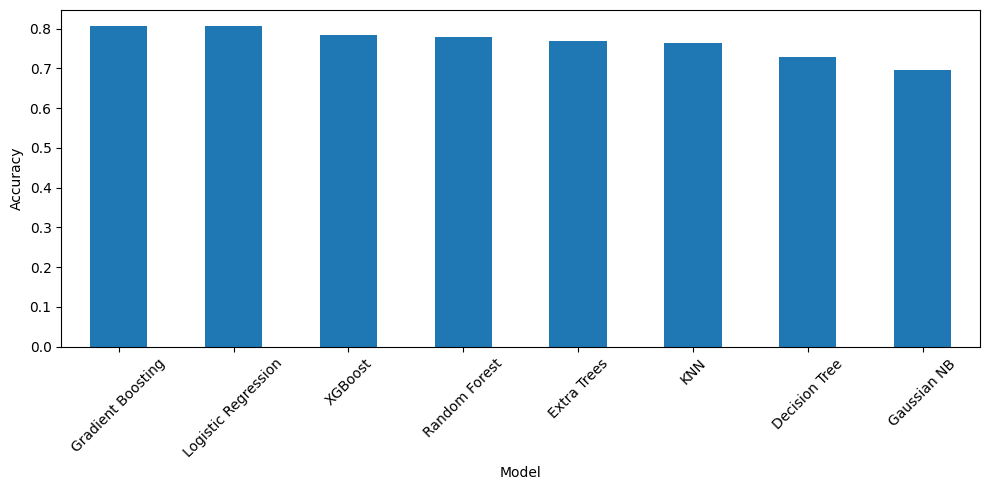

In [34]:
import matplotlib.pyplot as plt

results_df.plot(
    x="Model",
    y="Accuracy",
    kind="bar",
    legend=False,
    figsize=(10,5)
)

plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Final Model Selection, Saving, and Evaluation Report

This section compares all trained approaches on the same churn dataset, saves the best complete pipeline, and generates report files that can be used later for the written evaluation.

In [35]:
import json
from pathlib import Path

evaluation_rows = []
fitted_pipelines = {}
classification_reports = {}
confusion_matrices = {}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    start_time = time.time()
    pipe.fit(X_train, y_train)
    training_time = time.time() - start_time

    y_pred = pipe.predict(X_test)

    if hasattr(pipe, "predict_proba"):
        y_score = pipe.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_score)
    elif hasattr(pipe, "decision_function"):
        y_score = pipe.decision_function(X_test)
        roc_auc = roc_auc_score(y_test, y_score)
    else:
        roc_auc = np.nan

    cv_f1_scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring="f1",
        n_jobs=-1
    )

    evaluation_rows.append({
        "Approach": "Default preprocessing + default model",
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc,
        "CV F1 Mean": cv_f1_scores.mean(),
        "CV F1 Std": cv_f1_scores.std(),
        "Training Time (s)": training_time
    })

    fitted_pipelines[name] = pipe
    classification_reports[name] = classification_report(
        y_test,
        y_pred,
        target_names=["No Churn", "Churn"],
        zero_division=0,
        output_dict=True
    )
    confusion_matrices[name] = confusion_matrix(y_test, y_pred).tolist()

final_evaluation_df = pd.DataFrame(evaluation_rows)
final_evaluation_df = final_evaluation_df.sort_values(
    by=["ROC-AUC", "F1-Score", "Accuracy"],
    ascending=False
).reset_index(drop=True)

best_model_name = final_evaluation_df.loc[0, "Model"]
best_pipeline = fitted_pipelines[best_model_name]

model_path = Path("ml_15_best_churn_model.joblib")
joblib.dump(best_pipeline, model_path)

final_evaluation_df


,Approach,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,CV F1 Mean,CV F1 Std,Training Time (s)
0,Default preprocessing + default model,Gradient Boosting,0.806246,0.673540,0.524064,0.589474,0.843212,0.590727,0.023189,0.876830
1,Default preprocessing + default model,Logistic Regression,0.805536,0.657233,0.558824,0.604046,0.841874,0.591798,0.029758,0.044519
2,Default preprocessing + default model,XGBoost,0.784954,0.605970,0.542781,0.572638,0.825449,0.551118,0.023952,0.105243
3,Default preprocessing + default model,Random Forest,0.777857,0.603390,0.475936,0.532138,0.816366,0.540957,0.027894,0.512941
4,Default preprocessing + default model,Gaussian NB,0.694819,0.458944,0.836898,0.592803,0.807419,0.597406,0.009343,0.030529
5,Default preprocessing + default model,KNN,0.763662,0.552699,0.574866,0.563565,0.789767,0.547230,0.015945,0.028997
6,Default preprocessing + default model,Extra Trees,0.768630,0.573620,0.500000,0.534286,0.785240,0.516028,0.023862,0.522416
7,Default preprocessing + default model,Decision Tree,0.728886,0.489637,0.505348,0.497368,0.657266,0.498631,0.017242,0.057517


In [38]:
best_row = final_evaluation_df.iloc[0]
runner_up = final_evaluation_df.iloc[1]

report_lines = []

report_lines.append("Customer Churn Model Evaluation Report")
report_lines.append("=" * 39)
report_lines.append("")

report_lines.append("Dataset")
report_lines.append("-------")
report_lines.append("Source file: tel.csv")
report_lines.append(f"Rows: {len(df)}")
report_lines.append(f"Features used: {X.shape[1]}")
report_lines.append("Target: Churn, encoded as No=0 and Yes=1")
report_lines.append(f"Train rows: {len(X_train)}")
report_lines.append(f"Test rows: {len(X_test)}")
report_lines.append("")

report_lines.append("Approach")
report_lines.append("--------")
report_lines.append("All models were evaluated on the same stratified train/test split.")
report_lines.append("Numeric features were standardized with StandardScaler.")
report_lines.append("Categorical features were encoded with OneHotEncoder(handle_unknown='ignore').")
report_lines.append("Each model was wrapped in a single pipeline so preprocessing is saved together with the classifier.")
report_lines.append("")

report_lines.append("Models Compared")
report_lines.append("---------------")

for model_name in final_evaluation_df["Model"]:
    report_lines.append(f"- {model_name}")

report_lines.append("")

report_lines.append("Final Leaderboard")
report_lines.append("-----------------")

leaderboard_text = final_evaluation_df[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "CV F1 Mean",
        "Training Time (s)"
    ]
].to_string(index=False)

report_lines.append(leaderboard_text)
report_lines.append("")

report_lines.append("Winner")
report_lines.append("------")
report_lines.append(f"Best model: {best_model_name}")
report_lines.append(f"Accuracy: {best_row['Accuracy']:.4f}")
report_lines.append(f"Precision: {best_row['Precision']:.4f}")
report_lines.append(f"Recall: {best_row['Recall']:.4f}")
report_lines.append(f"F1-Score: {best_row['F1-Score']:.4f}")
report_lines.append(f"ROC-AUC: {best_row['ROC-AUC']:.4f}")
report_lines.append(f"Training time: {best_row['Training Time (s)']:.4f} seconds")
report_lines.append("")

report_lines.append("Justification")
report_lines.append("-------------")
report_lines.append(
    f"{best_model_name} was selected because it achieved the highest ROC-AUC, "
    f"with F1-score used as the secondary decision metric. ROC-AUC is useful for churn prediction "
    f"because it measures how well the model separates churn and non-churn customers across thresholds. "
    f"F1-score is also important because the churn class is less frequent, so accuracy alone can be misleading."
)

report_lines.append(
    f"The runner-up was {runner_up['Model']} with ROC-AUC {runner_up['ROC-AUC']:.4f} "
    f"and F1-score {runner_up['F1-Score']:.4f}."
)

report_lines.append("")

report_lines.append("Confusion Matrix for Best Model")
report_lines.append("-------------------------------")
report_lines.append("Format: [[True No Churn, False Churn], [False No Churn, True Churn]]")
report_lines.append(str(confusion_matrices[best_model_name]))
report_lines.append("")

report_lines.append("Classification Report for Best Model")
report_lines.append("------------------------------------")

best_report_df = pd.DataFrame(
    classification_reports[best_model_name]
).transpose()

report_lines.append(best_report_df.to_string())
report_lines.append("")

report_lines.append("Saved Artifacts")
report_lines.append("---------------")
report_lines.append(f"Best model pipeline: {model_path}")
report_lines.append("Evaluation CSV: ml_15_model_evaluation_report.csv")
report_lines.append("Classification reports JSON: ml_15_classification_reports.json")
report_lines.append("Confusion matrices JSON: ml_15_confusion_matrices.json")
report_lines.append("Text report: ml_15_evaluation_report.txt")

report_text = "\n".join(report_lines)

final_evaluation_df.to_csv(
    "ml_15_model_evaluation_report.csv",
    index=False
)

Path("ml_15_evaluation_report.txt").write_text(
    report_text,
    encoding="utf-8"
)

Path("ml_15_classification_reports.json").write_text(
    json.dumps(classification_reports, indent=2),
    encoding="utf-8"
)

Path("ml_15_confusion_matrices.json").write_text(
    json.dumps(confusion_matrices, indent=2),
    encoding="utf-8"
)

print(report_text)

Customer Churn Model Evaluation Report

Dataset
-------
Source file: tel.csv
Rows: 7043
Features used: 19
Target: Churn, encoded as No=0 and Yes=1
Train rows: 5634
Test rows: 1409

Approach
--------
All models were evaluated on the same stratified train/test split.
Numeric features were standardized with StandardScaler.
Categorical features were encoded with OneHotEncoder(handle_unknown='ignore').
Each model was wrapped in a single pipeline so preprocessing is saved together with the classifier.

Models Compared
---------------
- Gradient Boosting
- Logistic Regression
- XGBoost
- Random Forest
- Gaussian NB
- KNN
- Extra Trees
- Decision Tree

Final Leaderboard
-----------------
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC  CV F1 Mean  Training Time (s)
  Gradient Boosting  0.806246   0.673540 0.524064  0.589474 0.843212    0.590727           0.876830
Logistic Regression  0.805536   0.657233 0.558824  0.604046 0.841874    0.591798           0.044519
           